In [16]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0, vit_b_16
from torch.utils.data import DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter
from torch.optim.lr_scheduler import StepLR

In [17]:
# === CONFIG ===
DATA_DIR = "data_dog_breeds"
CHECKPOINT_DIR = "checkpoints"
RUNS_DIR = "runs"
EPOCHS = 10
BATCH_SIZE = 32
NUM_CLASSES = 8
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [18]:
def load_data(data_dir, batch_size):
    """Load the dataset and split it into training and validation sets."""
    # === TRANSFORM ===
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    # === DATASET ===
    full_dataset = datasets.ImageFolder(data_dir, transform=transform)
    class_names = full_dataset.classes
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
    # === DATALOADERS ===
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, class_names

In [26]:
# === VISUALIZE SOME PREDICTIONS ===
def show_predictions(model, dataloader, title, class_names):
    """Visualize some predictions from the model."""
    model.eval()
    images, labels = next(iter(dataloader))
    images, labels = images.to(DEVICE), labels.to(DEVICE)
    with torch.no_grad():
        outputs = model(images)
        preds = outputs.argmax(dim=1)

    fig, axs = plt.subplots(2, 4, figsize=(12, 6))
    axs = axs.flatten()
    for i in range(8):
        img = images[i].permute(1, 2, 0).cpu().numpy()
        img = (img * 0.5) + 0.5  # unnormalize
        axs[i].imshow(img)
        axs[i].axis("off")
        axs[i].set_title(f"GT: {class_names[labels[i]]}\nPred: {class_names[preds[i]]}")
    plt.suptitle(title)
    plt.tight_layout()
    # plt.savefig(f"{title.replace(' ', '_')}.png")
    print(f"Saved image predictions to: {title.replace(' ', '_')}.png")

In [27]:
# === MODEL SELECTOR ===
def get_model(name):
    if name == "efficientnet":
        model = efficientnet_b0(pretrained=True)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
    elif name == "vit":
        model = vit_b_16(pretrained=True)
        model.heads.head = nn.Linear(model.heads.head.in_features, NUM_CLASSES)
    else:
        raise ValueError("Unknown model")
    return model.to(DEVICE)

In [29]:
# === TRAIN FUNCTION ===
def train(model, model_name):
    writer = SummaryWriter(log_dir=os.path.join(RUNS_DIR, model_name))
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4) 
    scheduler = StepLR(optimizer, step_size=3, gamma=0.5)

    # === LOAD DATA ===
    train_loader, val_loader, class_names = load_data(DATA_DIR, BATCH_SIZE)

    for epoch in range(EPOCHS):
        model.train()
        train_loss, train_correct = 0.0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            train_correct += (outputs.argmax(1) == labels).sum().item()
        train_acc = train_correct / len(train_loader.dataset)

        # === VALIDATION ===
        model.eval()
        val_loss, val_correct = 0.0, 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                val_loss += criterion(outputs, labels).item()
                preds = outputs.argmax(1)
                val_correct += (preds == labels).sum().item()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        val_acc = val_correct / len(val_loader.dataset)

        # === LOGGING ===
        writer.add_scalar("Loss/train", train_loss, epoch)
        writer.add_scalar("Loss/val", val_loss, epoch)
        writer.add_scalar("Accuracy/train", train_acc, epoch)
        writer.add_scalar("Accuracy/val", val_acc, epoch)

        print(f"[{epoch+1}/{EPOCHS}] Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

        scheduler.step()

    writer.close()

    # === CONFUSION MATRIX ===
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(xticks_rotation=45)
    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    # plt.savefig(f"{model_name}_confusion_matrix.png")

    # === SHOW PREDICTIONS ===
    show_predictions(model, val_loader, f"{model_name} Sample Predictions", class_names)

    # === SAVE CHECKPOINT ===
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, f"{model_name}_model.pt"))
    print(f"Model saved to {CHECKPOINT_DIR}/{model_name}_model.pt")

# EfficientNet

[1/10] Train Acc: 0.4105 | Val Acc: 0.8705
[2/10] Train Acc: 0.9367 | Val Acc: 0.9353
[3/10] Train Acc: 0.9801 | Val Acc: 0.9568
[4/10] Train Acc: 0.9855 | Val Acc: 0.9856
[5/10] Train Acc: 0.9910 | Val Acc: 0.9712
[6/10] Train Acc: 0.9946 | Val Acc: 0.9784
[7/10] Train Acc: 0.9982 | Val Acc: 0.9712
[8/10] Train Acc: 0.9946 | Val Acc: 0.9784
[9/10] Train Acc: 1.0000 | Val Acc: 0.9712
[10/10] Train Acc: 0.9928 | Val Acc: 0.9712
Saved image predictions to: efficientnet_Sample_Predictions.png
Model saved to checkpoints/efficientnet_model.pt


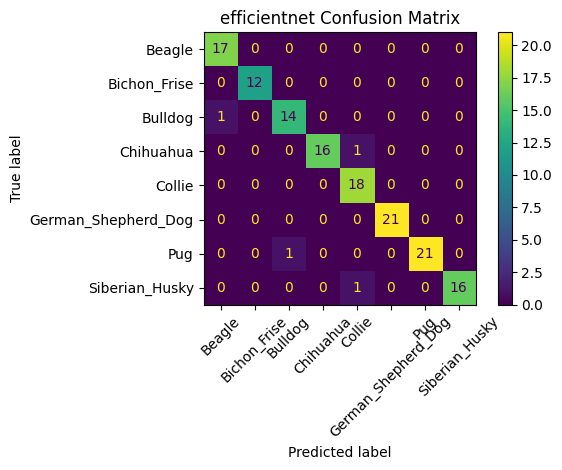

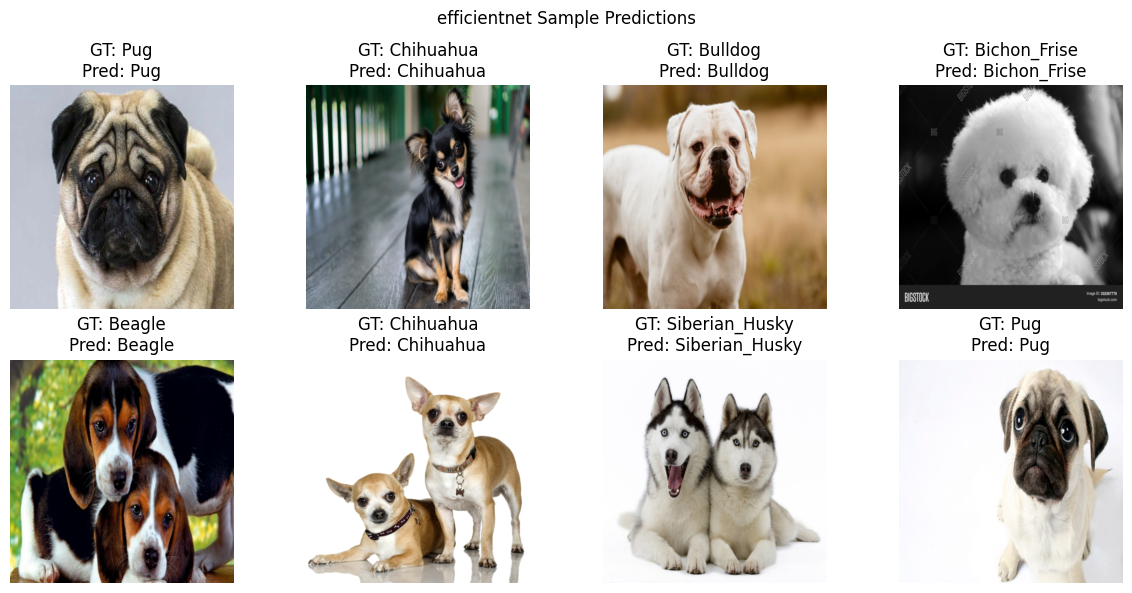

In [30]:
train(get_model("efficientnet"), "efficientnet")

# Vision Transformer

/home/wins057/miniconda3/envs/python_ml/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/wins057/miniconda3/envs/python_ml/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


[1/10] Train Acc: 0.5172 | Val Acc: 0.8777
[2/10] Train Acc: 0.9403 | Val Acc: 0.9209
[3/10] Train Acc: 0.9656 | Val Acc: 0.9640
[4/10] Train Acc: 0.9855 | Val Acc: 0.9712
[5/10] Train Acc: 0.9873 | Val Acc: 0.9712
[6/10] Train Acc: 0.9910 | Val Acc: 0.9712
[7/10] Train Acc: 0.9910 | Val Acc: 0.9712
[8/10] Train Acc: 0.9928 | Val Acc: 0.9712
[9/10] Train Acc: 0.9982 | Val Acc: 0.9784
[10/10] Train Acc: 0.9982 | Val Acc: 0.9784
Saved image predictions to: efficientnet_Sample_Predictions.png
Model saved to checkpoints/efficientnet_model.pt


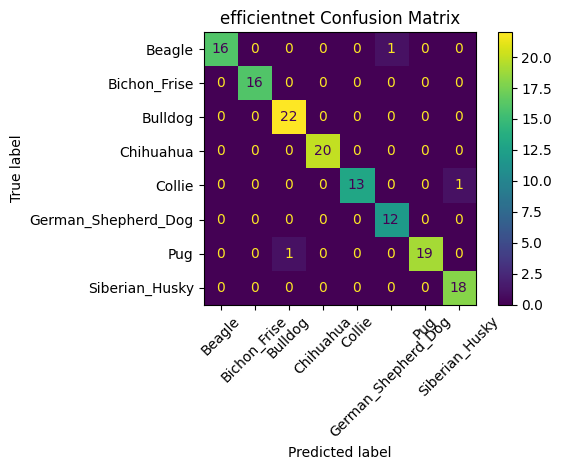

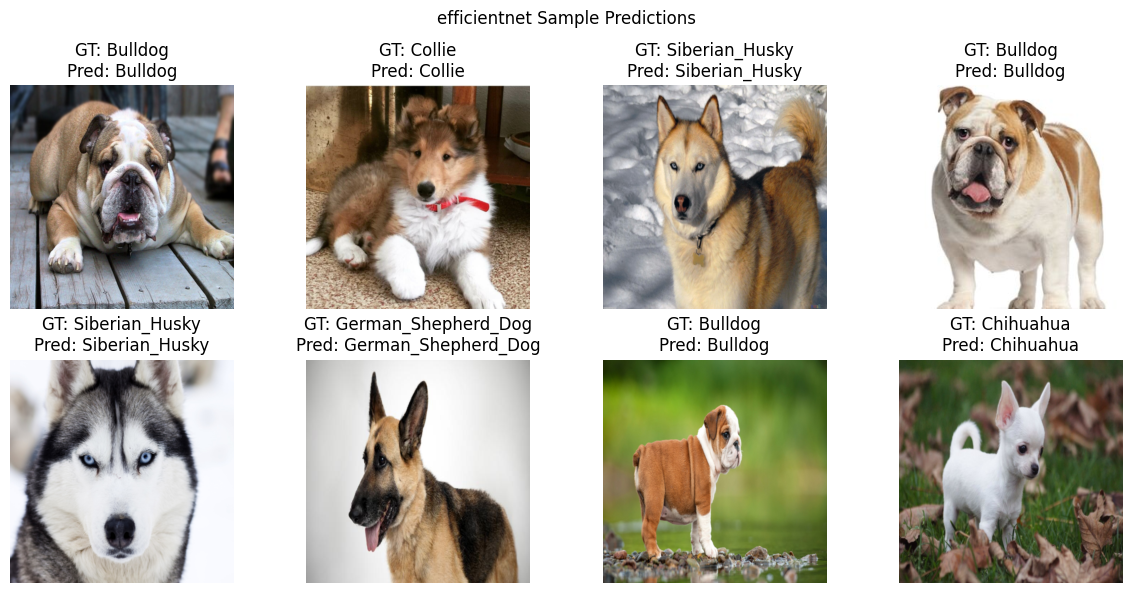

In [31]:
train(get_model("efficientnet"), "efficientnet")